# Equity Basics

Equity represents ownership in a company. Equity holders have a residual claim: after operating costs, taxes, interest, debt repayment, and other obligations, any remaining value belongs to shareholders.

Abbreviations used in this notebook:

- **EPS**: Earnings Per Share, net income divided by weighted average shares outstanding.
- **DPS**: Dividends Per Share, dividends paid divided by shares outstanding.
- **BVPS**: Book Value Per Share, common equity divided by shares outstanding.
- **EV**: Enterprise Value, value of the operating business independent of capital structure.
- **CHF**: Swiss franc, the currency used in the examples.

## 1. Intuition

A share is a unit of ownership. If a company has 100 shares and an investor owns 10 shares, that investor owns 10% of the equity. In public markets, shares trade continuously, so the market price per share changes as investors update their expectations about future cash flows, growth, risk, and required return.

Key equity concepts:

- **Common stock**: ordinary ownership claim, usually with voting rights.
- **Preferred stock**: equity-like claim that often has priority dividends but limited voting rights.
- **Shares outstanding**: shares currently issued and held by investors.
- **Treasury shares**: shares repurchased by the company and not counted as outstanding.
- **Dilution**: reduction in existing owners' percentage ownership when new shares are issued.
- **Market capitalization**: share price multiplied by shares outstanding.
- **Enterprise value**: market value of operating assets, often estimated as market cap plus net debt.
- **Dividends**: cash distributions paid to shareholders.
- **Retained earnings**: profits kept in the business instead of paid out as dividends.

> Equity is riskier than debt because shareholders are paid after lenders. The upside is that equity can participate in business growth.

## 2. Mathematics

**Ownership percentage:**

$$
\text{Ownership} = \frac{\text{Shares Owned}}{\text{Shares Outstanding}}
$$

Where:

- $\text{Shares Owned}$ = shares held by one investor
- $\text{Shares Outstanding}$ = total shares held by all investors
- $\text{Ownership}$ = investor's percentage claim on common equity

**Market capitalization:**

$$
\text{Market Cap} = \text{Share Price} \times \text{Shares Outstanding}
$$

Where:

- $\text{Share Price}$ = market price per share
- $\text{Shares Outstanding}$ = shares currently held by investors
- $\text{Market Cap}$ = total equity market value

**Enterprise value:**

$$
EV = \text{Market Cap} + \text{Debt} - \text{Cash}
$$

Where:

- $EV$ = enterprise value
- $\text{Market Cap}$ = market value of common equity
- $\text{Debt}$ = interest-bearing debt
- $\text{Cash}$ = cash and cash equivalents

**Earnings per share:**

$$
EPS = \frac{\text{Net Income} - \text{Preferred Dividends}}{\text{Weighted Average Common Shares}}
$$

Where:

- $EPS$ = earnings per common share
- $\text{Net Income}$ = profit after all expenses and taxes
- $\text{Preferred Dividends}$ = dividends owed to preferred shareholders
- $\text{Weighted Average Common Shares}$ = average common shares outstanding during the period

**Book value per share:**

$$
BVPS = \frac{\text{Common Equity}}{\text{Common Shares Outstanding}}
$$

Where:

- $BVPS$ = book value per share
- $\text{Common Equity}$ = book value of equity attributable to common shareholders
- $\text{Common Shares Outstanding}$ = common shares currently held by investors

**Dividend yield:**

$$
\text{Dividend Yield} = \frac{\text{Annual Dividend Per Share}}{\text{Share Price}}
$$

Where:

- $\text{Annual Dividend Per Share}$ = expected or trailing annual dividends paid per share
- $\text{Share Price}$ = current market price per share
- $\text{Dividend Yield}$ = cash dividend return relative to share price

**Dividend payout ratio:**

$$
\text{Payout Ratio} = \frac{\text{Dividends}}{\text{Net Income}}
$$

Where:

- $\text{Dividends}$ = total dividends paid to shareholders
- $\text{Net Income}$ = profit after all expenses and taxes
- $\text{Payout Ratio}$ = share of earnings distributed as dividends


## 3. Implementation

We will create a small equity profile for a public company and calculate the core per-share and ownership measures. The numbers are synthetic and simplified.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8-whitegrid")
pd.options.display.float_format = "{:,.4f}".format

In [2]:
share_price = 105.0
shares_outstanding = 2_650_000_000
treasury_shares = 80_000_000
debt = 42_000_000_000
cash = 11_500_000_000
net_income = 9_200_000_000
preferred_dividends = 0
common_equity = 58_000_000_000
annual_dividend_per_share = 3.10
investor_shares = 1_000_000

market_cap = share_price * shares_outstanding
enterprise_value = market_cap + debt - cash
eps = (net_income - preferred_dividends) / shares_outstanding
bvps = common_equity / shares_outstanding
dividend_yield = annual_dividend_per_share / share_price
total_dividends = annual_dividend_per_share * shares_outstanding
payout_ratio = total_dividends / net_income
ownership = investor_shares / shares_outstanding

equity_summary = pd.DataFrame({
    "metric": [
        "Share price",
        "Shares outstanding",
        "Market capitalization",
        "Enterprise value",
        "Earnings per share",
        "Book value per share",
        "Annual dividend per share",
        "Dividend yield",
        "Payout ratio",
        "Investor ownership",
    ],
    "value": [
        f"CHF {share_price:,.2f}",
        f"{shares_outstanding:,.0f}",
        f"CHF {market_cap / 1_000_000_000:,.1f}bn",
        f"CHF {enterprise_value / 1_000_000_000:,.1f}bn",
        f"CHF {eps:,.2f}",
        f"CHF {bvps:,.2f}",
        f"CHF {annual_dividend_per_share:,.2f}",
        f"{dividend_yield:.2%}",
        f"{payout_ratio:.1%}",
        f"{ownership:.4%}",
    ],
})

equity_summary

,metric,value
0,Share price,CHF 105.00
1,Shares outstanding,"2,650,000,000"
2,Market capitalization,CHF 278.2bn
3,Enterprise value,CHF 308.8bn
4,Earnings per share,CHF 3.47
5,Book value per share,CHF 21.89
6,Annual dividend per share,CHF 3.10
7,Dividend yield,2.95%
8,Payout ratio,89.3%
9,Investor ownership,0.0377%


Dilution matters because ownership is a fraction. If the company issues new shares, the same number of investor shares represents a smaller percentage of the company unless the investor buys more shares.

In [3]:
new_shares_issued = 150_000_000
post_issue_shares = shares_outstanding + new_shares_issued

ownership_before = investor_shares / shares_outstanding
ownership_after = investor_shares / post_issue_shares
dilution = 1 - ownership_after / ownership_before

dilution_summary = pd.DataFrame({
    "metric": [
        "Investor shares",
        "Shares before issuance",
        "Shares after issuance",
        "Ownership before",
        "Ownership after",
        "Relative dilution",
    ],
    "value": [
        f"{investor_shares:,.0f}",
        f"{shares_outstanding:,.0f}",
        f"{post_issue_shares:,.0f}",
        f"{ownership_before:.4%}",
        f"{ownership_after:.4%}",
        f"{dilution:.2%}",
    ],
})

dilution_summary

,metric,value
0,Investor shares,"1,000,000"
1,Shares before issuance,"2,650,000,000"
2,Shares after issuance,"2,800,000,000"
3,Ownership before,0.0377%
4,Ownership after,0.0357%
5,Relative dilution,5.36%


## 4. Visualization

Equity visuals often show ownership structure, value bridges, and per-share metrics. The examples below show how market capitalization turns into enterprise value and how a share issuance changes ownership percentage.

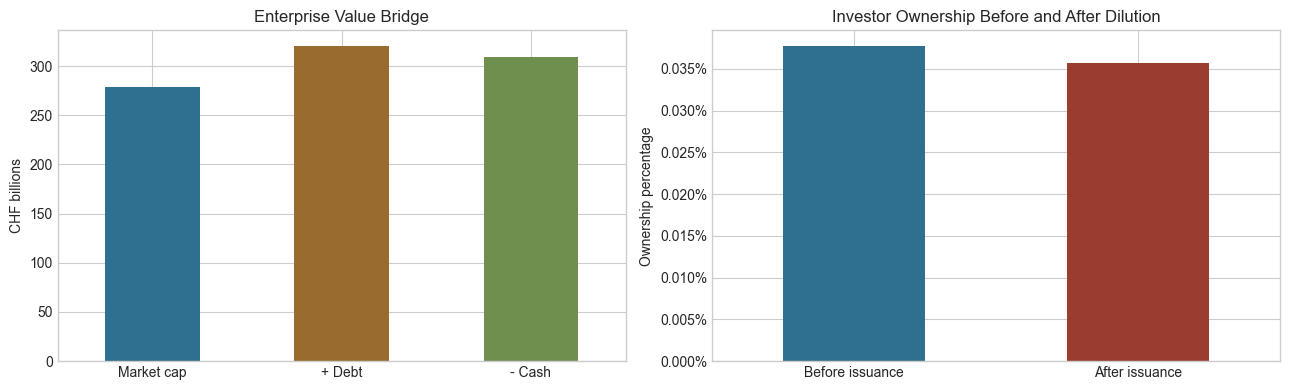

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

ev_bridge = pd.Series({
    "Market cap": market_cap / 1_000_000_000,
    "+ Debt": debt / 1_000_000_000,
    "- Cash": -cash / 1_000_000_000,
})
ev_bridge.cumsum().plot(kind="bar", ax=axes[0], color=["#2f6f8f", "#9a6b2f", "#6f8f4e"])
axes[0].set_title("Enterprise Value Bridge")
axes[0].set_ylabel("CHF billions")
axes[0].tick_params(axis="x", rotation=0)

ownership_series = pd.Series({
    "Before issuance": ownership_before,
    "After issuance": ownership_after,
})
ownership_series.plot(kind="bar", ax=axes[1], color=["#2f6f8f", "#9a3d2f"])
axes[1].set_title("Investor Ownership Before and After Dilution")
axes[1].set_ylabel("Ownership percentage")
axes[1].yaxis.set_major_formatter(lambda x, pos: f"{x:.3%}")
axes[1].tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.show()

## 5. Application

Equity basics help connect financial statements to market valuation:

- Share count connects company-level value to per-share value.
- Market cap shows the value investors assign to the common equity.
- Enterprise value adjusts market cap for debt and cash to approximate the value of the operating business.
- EPS connects profitability to each common share.
- Dividend yield connects cash distributions to the current share price.
- Dilution helps explain why issuing shares can reduce existing ownership percentages.
- Treasury shares matter because repurchased shares are not counted as outstanding shares.

## 6. Reflection

- Equity is ownership and a residual claim on company value.
- Share count is central because many equity measures are calculated per share.
- Market cap values equity; enterprise value values the operating business more directly.
- Common shareholders usually have voting rights but stand behind creditors in liquidation.
- Dividends distribute cash to shareholders, while retained earnings keep profits in the business.
- Dilution reduces existing shareholders' percentage ownership when new shares are issued.

Questions to answer after running the notebook:

1. Why is equity considered a residual claim?
2. Why can market cap and enterprise value differ meaningfully?
3. How does issuing new shares dilute existing shareholders?
4. Why do analysts often focus on per-share metrics such as EPS?